In [1]:
import tensorflow as tf

# Konfigurasi untuk menggunakan GPU Lokal
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        # Mengaktifkan memory growth agar TensorFlow tidak memakan seluruh VRAM secara langsung
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"Ditemukan {len(gpus)} GPU(s) lokal. Pelatihan akan menggunakan GPU.")
    except RuntimeError as e:
        print(e)
else:
    print("PERINGATAN: GPU tidak ditemukan! Pastikan CUDA dan cuDNN sudah terinstal. Pelatihan akan berjalan di CPU.")

I0000 00:00:1778802577.621564     681 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778802578.282160     681 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778802580.949832     681 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Ditemukan 1 GPU(s) lokal. Pelatihan akan menggunakan GPU.


In [2]:
import os
import numpy as np
import tensorflow as tf
from sklearn.utils.class_weight import compute_class_weight

IMG_SIZE = 224 # Diperbesar dari 96 ke 224 sesuai spesifikasi
BATCH_SIZE = 64
NUM_CLASSES = 7
TRAIN_DIR = 'dataset_rafdb/train'
TEST_DIR = 'dataset_rafdb/test'

# 1. Pipeline Training
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=True
)

# 2. Pipeline Validasi
val_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=False
)

# Hitung Class Weights untuk menangani Imbalance
class_names = sorted(os.listdir(TRAIN_DIR))
y_train = []
for i, c in enumerate(class_names):
    count = len(os.listdir(os.path.join(TRAIN_DIR, c)))
    y_train.extend([i] * count)
y_train = np.array(y_train)

class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights_arr)}

print("Class Names:", class_names)
print("Class Weights yang dihitung:", class_weight_dict)

# Optimasi CPU-to-GPU Handoff
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

Found 12271 files belonging to 7 classes.


I0000 00:00:1778802586.340743     681 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5563 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Found 3068 files belonging to 7 classes.
Class Names: ['1', '2', '3', '4', '5', '6', '7']
Class Weights yang dihitung: {0: np.float64(1.3589147286821706), 1: np.float64(6.238434163701068), 2: np.float64(2.4449093444909344), 3: np.float64(0.3673512154233026), 4: np.float64(0.884460141271443), 5: np.float64(2.4865248226950354), 6: np.float64(0.6945324881141046)}


In [3]:
# --- ADVANCED: tf.data Random Oversampling (Rejection Resample) ---
# JIKA ANDA INGIN MENGGUNAKAN OVERSAMPLING ALIH-ALIH CLASS WEIGHTS, BACA BAGIAN INI.
# Karena penggunaan Class Weights dan Oversampling sekaligus bisa menyebabkan Over-Correction, 
# kita default ke class weights yang lebih efisien di Keras. Namun, jika ingin mencoba oversampling:

'''
class_counts = [len(os.listdir(os.path.join(TRAIN_DIR, c))) for c in class_names]
initial_dist = [count / len(y_train) for count in class_counts]
target_dist = [1.0/NUM_CLASSES] * NUM_CLASSES

resampler = tf.data.experimental.rejection_resample(
    class_func=lambda x, y: tf.argmax(y, axis=0),
    target_dist=target_dist,
    initial_dist=initial_dist
)

train_ds_unbatched = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, image_size=(IMG_SIZE, IMG_SIZE), batch_size=None, label_mode='categorical', shuffle=True
)

resampled_train_ds = train_ds_unbatched.apply(resampler).map(
    lambda class_val, data: data
).batch(BATCH_SIZE).prefetch(buffer_size=AUTOTUNE)
'''
# Jika ingin pakai `resampled_train_ds`, gunakan itu di model.fit dan hapus argumen `class_weight`.


"\nclass_counts = [len(os.listdir(os.path.join(TRAIN_DIR, c))) for c in class_names]\ninitial_dist = [count / len(y_train) for count in class_counts]\ntarget_dist = [1.0/NUM_CLASSES] * NUM_CLASSES\n\nresampler = tf.data.experimental.rejection_resample(\n    class_func=lambda x, y: tf.argmax(y, axis=0),\n    target_dist=target_dist,\n    initial_dist=initial_dist\n)\n\ntrain_ds_unbatched = tf.keras.utils.image_dataset_from_directory(\n    TRAIN_DIR, image_size=(IMG_SIZE, IMG_SIZE), batch_size=None, label_mode='categorical', shuffle=True\n)\n\nresampled_train_ds = train_ds_unbatched.apply(resampler).map(\n    lambda class_val, data: data\n).batch(BATCH_SIZE).prefetch(buffer_size=AUTOTUNE)\n"

In [4]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Input
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomContrast, RandomZoom, Rescaling
from tensorflow.keras.models import Model, Sequential

# 0. Enhanced Data Augmentation (Dieksekusi oleh GPU)
data_augmentation = Sequential([
    Rescaling(1./255),
    RandomFlip("horizontal"),
    RandomRotation(factor=0.15),
    RandomContrast(factor=0.2),
    RandomZoom(height_factor=0.1, width_factor=0.1)
], name="data_augmentation")

# 1. Load Pre-trained Base Model
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Freeze the base for Phase 1
base_model.trainable = False

# 2. Bangun Custom Classification Head dengan Augmentasi
inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = data_augmentation(inputs)
x = base_model(x, training=False) # Pastikan BatchNormalization layer berjalan dalam inference mode (sangat penting untuk fine-tuning)
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x) # Tambahkan Dropout 0.5 untuk mencegah overfitting
predictions = Dense(NUM_CLASSES, activation='softmax')(x)

# 3. Satukan menjadi model utuh
model = Model(inputs=inputs, outputs=predictions)
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 5s 1us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 7)              │         8,967 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,266,951 (8.65 MB)

 Trainable params: 8,967 (35.03 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [5]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

callbacks = [
    ModelCheckpoint('samaya_rafdb_mobilenetv2_optimized.keras', monitor='val_accuracy', save_best_only=True, mode='max', verbose=1),
    # Early stopping dengan patience 8
    EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1),
    # ReduceLROnPlateau jika validasi loss tidak turun dalam 3 epoch
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-7, verbose=1)
]

In [6]:
from tensorflow.keras.optimizers import Adam

print("=== PHASE 1: Training Custom Head Only ===")
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

EPOCHS_PHASE_1 = 10

# Melatih bagian head model
history_phase1 = model.fit(
    train_ds, 
    validation_data=val_ds,
    epochs=EPOCHS_PHASE_1,
    callbacks=callbacks,
    class_weight=class_weight_dict # Kita pakai class_weight untuk koreksi imbalance
)

=== PHASE 1: Training Custom Head Only ===
Epoch 1/10


I0000 00:00:1778802601.881635     863 cuda_dnn.cc:461] Loaded cuDNN version 92200


192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - accuracy: 0.2063 - loss: 2.3552
Epoch 1: val_accuracy improved from None to 0.41167, saving model to samaya_rafdb_mobilenetv2_optimized.keras

Epoch 1: finished saving model to samaya_rafdb_mobilenetv2_optimized.keras
192/192 ━━━━━━━━━━━━━━━━━━━━ 45s 186ms/step - accuracy: 0.2454 - loss: 2.1833 - val_accuracy: 0.4117 - val_loss: 1.5670 - learning_rate: 0.0010
Epoch 2/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.3205 - loss: 1.8084
Epoch 2: val_accuracy improved from 0.41167 to 0.43579, saving model to samaya_rafdb_mobilenetv2_optimized.keras

Epoch 2: finished saving model to samaya_rafdb_mobilenetv2_optimized.keras
192/192 ━━━━━━━━━━━━━━━━━━━━ 21s 110ms/step - accuracy: 0.3302 - loss: 1.8118 - val_accuracy: 0.4358 - val_loss: 1.5127 - learning_rate: 0.0010
Epoch 3/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.3640 - loss: 1.6932
Epoch 3: val_accuracy did not improve from 0.43579
192/192 ━━━━━━━━━━━━━━━━━━━━ 21s 10

In [7]:
print("=== PHASE 2: Fine-Tuning Top 30 Layers of Base Model ===")

# Unfreeze base model
base_model.trainable = True

# Freeze all layers except the top 30
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Compile lagi dengan learning rate yang JAUH lebih rendah (1e-5)
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

EPOCHS_PHASE_2 = 30 # Bebas disesuaikan, early stopping akan menghentikannya jika sudah overfit

history_phase2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_PHASE_2,
    callbacks=callbacks,
    class_weight=class_weight_dict # Tetap pakai class weight
)

=== PHASE 2: Fine-Tuning Top 30 Layers of Base Model ===


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 7)              │         8,967 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,266,951 (8.65 MB)

 Trainable params: 1,535,367 (5.86 MB)

 Non-trainable params: 731,584 (2.79 MB)

Epoch 1/30
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - accuracy: 0.2492 - loss: 2.0577
Epoch 1: val_accuracy improved from 0.47001 to 0.50489, saving model to samaya_rafdb_mobilenetv2_optimized.keras

Epoch 1: finished saving model to samaya_rafdb_mobilenetv2_optimized.keras
192/192 ━━━━━━━━━━━━━━━━━━━━ 43s 170ms/step - accuracy: 0.2608 - loss: 1.9891 - val_accuracy: 0.5049 - val_loss: 1.4030 - learning_rate: 1.0000e-05
Epoch 2/30
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.3100 - loss: 1.7616
Epoch 2: val_accuracy improved from 0.50489 to 0.51597, saving model to samaya_rafdb_mobilenetv2_optimized.keras

Epoch 2: finished saving model to samaya_rafdb_mobilenetv2_optimized.keras
192/192 ━━━━━━━━━━━━━━━━━━━━ 30s 155ms/step - accuracy: 0.3328 - loss: 1.7110 - val_accuracy: 0.5160 - val_loss: 1.3485 - learning_rate: 1.0000e-05
Epoch 3/30
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.3681 - loss: 1.6562
Epoch 3: val_accuracy improved from 0.51597 to 0.52021, saving

Sedang melakukan inferensi pada data validasi dengan model terbaik...
48/48 ━━━━━━━━━━━━━━━━━━━━ 6s 93ms/step
=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           1       0.64      0.65      0.64       329
           2       0.30      0.46      0.36        74
           3       0.23      0.52      0.31       160
           4       0.90      0.65      0.76      1185
           5       0.63      0.54      0.58       478
           6       0.48      0.59      0.53       162
           7       0.59      0.69      0.64       680

    accuracy                           0.63      3068
   macro avg       0.54      0.59      0.55      3068
weighted avg       0.69      0.63      0.65      3068



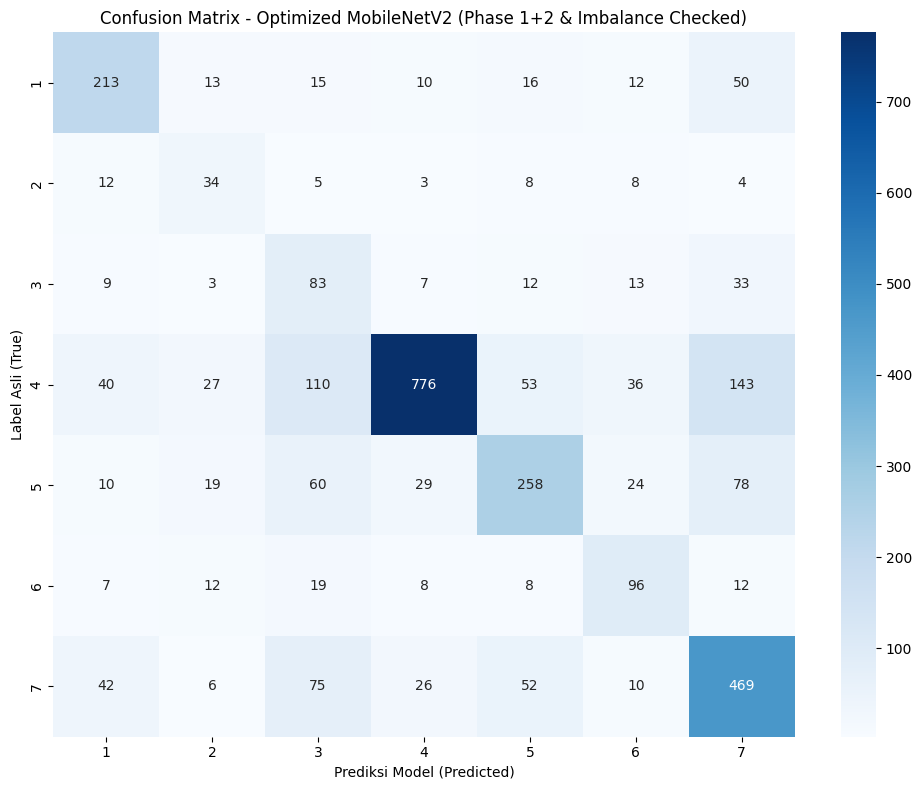

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report, confusion_matrix

print("Sedang melakukan inferensi pada data validasi dengan model terbaik...")
# Muat model terbaik yang disimpan
best_model = load_model('samaya_rafdb_mobilenetv2_optimized.keras')

predictions = best_model.predict(val_ds, verbose=1)
y_pred = np.argmax(predictions, axis=1)

y_true = np.concatenate([y for x, y in val_ds], axis=0)
y_true = np.argmax(y_true, axis=1)

print("=== CLASSIFICATION REPORT ===")
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Optimized MobileNetV2 (Phase 1+2 & Imbalance Checked)')
plt.ylabel('Label Asli (True)')
plt.xlabel('Prediksi Model (Predicted)')
plt.tight_layout()
plt.savefig('samaya_rafdb_confusion_matrix_optimized.png', dpi=300)
plt.show()